# TensorFlow

In [ ]:

import tensorflow as tf


In [ ]:
# 1
import tensorflow as tf
tf.random.set_seed(42)

t1 = tf.constant([1,2,3,4,5])
t2 = tf.random.normal(shape=(3,3))
v1 = tf.Variable(tf.zeros(shape=(2,4)))

for name, t in [('Tensor 1', t1), ('Tensor 2', t2), ('Variable', v1)]:
  print(f'{name} shape:{t.shape} dtype:{t.dtype.name} rank:{tf.rank(t).numpy()}')

Tensor 1 shape:(5,) dtype:int32 rank:1
Tensor 2 shape:(3, 3) dtype:float32 rank:2
Variable shape:(2, 4) dtype:float32 rank:2


In [ ]:
# 2
import tensorflow as tf
tf.random.set_seed(42)

A = tf.random.normal(shape=(2,3))
B = tf.random.normal(shape=(2,3))
print('A:', A)
print('B:', B)
print(f'Add : ',tf.add(A,B))
print(f'Multiply : ',tf.matmul(A,tf.transpose(B)))
print(f'Mean of A : ',tf.reduce_mean(A))
print(f'Mean of B: ',tf.reduce_mean(B))
print('A + B shape: ',tf.add(A,B).shape)
print('A * B shape: ',tf.matmul(A,tf.transpose(B)).shape)
print('Mean of A: ',tf.reduce_mean(A).numpy())
print('Mean of B: ',tf.reduce_mean(B).numpy())


A: tf.Tensor(
[[ 0.3274685 -0.8426258  0.3194337]
 [-1.4075519 -2.3880599 -1.0392479]], shape=(2, 3), dtype=float32)
B: tf.Tensor(
[[ 0.08422458 -0.86090374  0.37812304]
 [-0.00519627 -0.49453196  0.6178192 ]], shape=(2, 3), dtype=float32)
Add :  tf.Tensor(
[[ 0.4116931  -1.7035296   0.69755673]
 [-1.4127482  -2.8825917  -0.42142868]], shape=(2, 3), dtype=float32)
Multiply :  tf.Tensor(
[[0.87378585 0.61235607]
 [1.5443757  0.5462186 ]], shape=(2, 2), dtype=float32)
Mean of A :  tf.Tensor(-0.8384306, shape=(), dtype=float32)
Mean of B:  tf.Tensor(-0.046744186, shape=(), dtype=float32)
A + B shape:  (2, 3)
A * B shape:  (2, 2)
Mean of A:  -0.8384306
Mean of B:  -0.046744186


In [ ]:
# 3
import tensorflow as tf
from tensorflow import keras
model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([keras.layers.Dense(64, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print('Optimizer : ',model.optimizer.get_config()['name'])
print('Loss : ',model.loss)
print('Metrics : ',[m.name for m in model.metrics])

Optimizer :  adam
Loss :  sparse_categorical_crossentropy
Metrics :  ['loss', 'compile_metrics']


In [ ]:
# 5
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255
x_te = x_te.reshape(-1, 784) / 255

model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_tr, y_tr, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
loss, acc = model.evaluate(x_tr, y_tr, verbose=0)
print(f'Test Accuracy : {acc:.4f}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8992 - loss: 0.3561 - val_accuracy: 0.9595 - val_loss: 0.1413
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9566 - loss: 0.1493 - val_accuracy: 0.9685 - val_loss: 0.1084
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9701 - loss: 0.1037 - val_accuracy: 0.9722 - val_loss: 0.0975
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9775 - loss: 0.0780 - val_accuracy: 0.9743 - val_loss: 0.0946
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9824 - loss: 0.0609 - val_accuracy: 0.9748 - val_loss: 0.0943
Test Accuracy : 0.9803


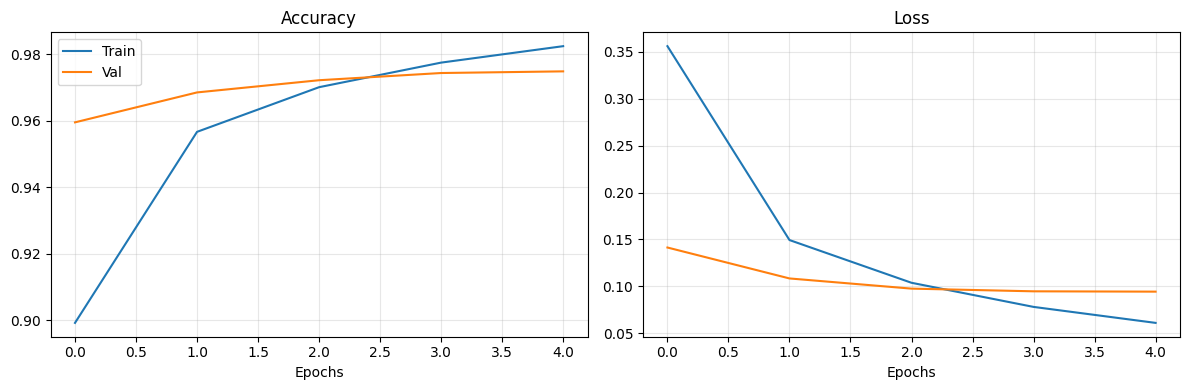

In [ ]:
# 6
import matplotlib.pyplot as plt
# history = result of model.fit([keras.layers.Dense(128, activation='relu', input_shape=(784,)), keras.layers.Dense(64, activation='relu'), keras.layers.Dense(10, activation='softmax')])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epochs')
axes[1].legend
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tf_history.png', dpi=100)
plt.show()

In [ ]:
# 7
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0

model_drop = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                                keras.layers.Dropout(0.2),
                                keras.layers.Dense(64, activation='relu'),
                                keras.layers.Dropout(0.2),
                                keras.layers.Dense(10, activation='softmax')])
model_drop.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist = model_drop.fit(x_tr, y_tr, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
print('Final val_accuracy with Dropout: ',round(hist.history['val_accuracy'][-1],4))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8564 - loss: 0.4801 - val_accuracy: 0.9572 - val_loss: 0.1555
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9369 - loss: 0.2153 - val_accuracy: 0.9680 - val_loss: 0.1118
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9529 - loss: 0.1618 - val_accuracy: 0.9700 - val_loss: 0.0969
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9609 - loss: 0.1334 - val_accuracy: 0.9773 - val_loss: 0.0839
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9658 - loss: 0.1148 - val_accuracy: 0.9780 - val_loss: 0.0792
Final val_accuracy with Dropout:  0.978


In [ ]:
# 8
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0

model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_tr, y_tr, epochs=5, batch_size=128, verbose=0)

model.save('path.keras')
loaded = keras.models.load_model('path.keras')
original_model_loss, org_acc = model.evaluate(x_te, y_te, verbose=0)
loaded_model_loss, load_acc = loaded.evaluate(x_te, y_te, verbose=0)
print(f'Original Accuracy : {org_acc:.4f}')
print(f'Loaded Accuracy : {load_acc:.4f}')


Original Accuracy : 0.9726
Loaded Accuracy : 0.9726


In [ ]:
# 9
from tensorflow import keras
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
tf.random.set_seed(42)

x, y = load_breast_cancer(return_X_y=True)
x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42)
sc = StandardScaler()
x_tr = sc.fit_transform(x_tr)
x_te = sc.transform(x_te)

model = keras.Sequential([keras.layers.Dense(32, activation='relu', input_shape=(30,)),
                          keras.layers.Dense(16, activation='relu'),
                          keras.layers.Dense(1, activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_tr, y_tr, epochs=20, batch_size=32, validation_split=0.15, verbose=0)
binary_crossentropy_loss, acc = model.evaluate(x_te, y_te, verbose=0)
print(f'Test Accuracy : {acc:.4f}')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy : 0.9737


In [ ]:
# 10
from tensorflow import keras
import tensorflow as tf
import numpy as np
tf.random.set_seed(42)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

(x_tr, y_tr), (x_te, y_te) = keras.datasets.fashion_mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0
y_tr_oh = keras.utils.to_categorical(y_tr, 10)
y_te_oh = keras.utils.to_categorical(y_te, 10)

model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_tr, y_tr_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
loss, acc= model.evaluate(x_te, y_te_oh, verbose=0)
print(f'Test Accuracy : {acc:.4f}')
pred = np.argmax(model.predict(x_te[:1], verbose=0))
print('Predicted class: ',class_names[pred])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Test Accuracy : 0.8704
Predicted class:  Ankle boot


In [ ]:
# 11
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 28, 28, 1) / 255.0
x_te = x_te.reshape(-1, 28, 28, 1) / 255.0

cnn = keras.Sequential([keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Conv2D(64, (3,3), activation='relu'),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Flatten(),
                        keras.layers.Dense(64, activation='relu'),
                        keras.layers.Dense(10, activation='softmax')])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
loss, acc = cnn.evaluate(x_te, y_te, verbose=0)
print(f'Test Accuracy : {acc:.4f}')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 68s 75ms/step - accuracy: 0.9483 - loss: 0.1754 - val_accuracy: 0.9815 - val_loss: 0.0617
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 71s 63ms/step - accuracy: 0.9843 - loss: 0.0518 - val_accuracy: 0.9863 - val_loss: 0.0445
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 78s 58ms/step - accuracy: 0.9892 - loss: 0.0351 - val_accuracy: 0.9867 - val_loss: 0.0466
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 77s 52ms/step - accuracy: 0.9921 - loss: 0.0253 - val_accuracy: 0.9873 - val_loss: 0.0479
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.9823 - val_loss: 0.0672
Test Accuracy : 0.9827


In [ ]:
# 12
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0

model = keras.Sequential([keras.layers.Dense(128, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
mc = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
hist = model.fit(x_tr, y_tr, epochs=20, batch_size=128, validation_split=0.1, callbacks=[es, mc], verbose=0)
print(f'Stopped at epoch: {len(hist.history["loss"])}')
loss, acc = model.evaluate(x_te, y_te, verbose=0)
print(f'Test Accuracy : {acc:.4f}')


Stopped at epoch: 7
Test Accuracy : 0.9686


In [ ]:
# 13
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
tf.random.set_seed(42)

x, y = load_iris(return_X_y=True)
x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=4)
sc = StandardScaler()
x_tr = sc.fit_transform(x_tr).astype('float32')
x_te = sc.transform(x_te).astype('float32')

model = keras.Sequential([keras.layers.Dense(32, activation='relu', input_shape=(4,)),
                          keras.layers.Dense(3, activation='softmax')])
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=0.001)

for epoch in range(1, 101):
  with tf.GradientTape() as tape:
    logits = model(x_tr, training=True)
    loss = loss_fn(y_tr, logits)
  grads = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if epoch % 20 == 0:
    preds = tf.argmax(model(x_tr), axis=1).numpy()
    acc = (preds == y_tr).mean()
    print(f'Epoch {epoch:3d} -- accuracy: {acc:.3f}')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch  20 -- accuracy: 0.600
Epoch  40 -- accuracy: 0.633
Epoch  60 -- accuracy: 0.650
Epoch  80 -- accuracy: 0.758
Epoch 100 -- accuracy: 0.867


In [ ]:
# 14
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(x_tr, y_tr), (x_te, y_te) = keras.datasets.fashion_mnist.load_data()
x_tr = x_tr.reshape(-1, 784) / 255.0
x_te = x_te.reshape(-1, 784) / 255.0

# plain model
plain = keras.Sequential([keras.layers.Dense(256, activation='relu', input_shape=(784,)),
                          keras.layers.Dense(128, activation='relu'),
                          keras.layers.Dense(10, activation='softmax')])

# Model with BN + L2
reg = keras.regularizers.l2(0.001)
bn_model = keras.Sequential([keras.layers.Dense(256, activation='relu', kernel_regularizer=reg, input_shape=(784,)),
                            keras.layers.BatchNormalization(),
                            keras.layers.Dense(128, activation='softmax')])

for name, m in [('Plain', plain), ('Bn + L2', bn_model)]:
  m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  h = m.fit(x_tr, y_tr, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
  loss, acc = m.evaluate(x_te, y_te, verbose=0)
  print(f'{name} val_accuracy : {h.history["val_accuracy"][-1]:.4f} params: {m.count_params()}')



Plain val_accuracy : 0.8917 params: 235146
Bn + L2 val_accuracy : 0.8160 params: 234880


In [ ]:
# 15
from tensorflow import keras
import tensorflow as tf, numpy as np
tf.random.set_seed(42)

base = keras.applications.MobileNetV2(input_shape=(96,96,3), include_top = False, weights='imagenet')
base.trainable = 'Freeze'

model = keras.Sequential([base,
                        keras.layers.GlobalAveragePooling2D(),
                        keras.layers.Dense(64, activation='relu'),
                        keras.layers.Dropout(0.3),
                        keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Dummy data to verify pipeline
x_dummy = np.random.rand(200, 96, 96, 3).astype('float32')
y_dummy = np.random.randint(0, 10, 200)
model.fit(x_dummy, y_dummy, epochs=3, batch_size=16, verbose=1)

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f'Trainable params: {trainable:,}')
print(f'Non-trainable params: {non_trainable:,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 500ms/step - accuracy: 0.0750 - loss: 2.7569
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 608ms/step - accuracy: 0.4500 - loss: 1.6114
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 506ms/step - accuracy: 0.7650 - loss: 0.7640
Trainable params: 2,306,506
Non-trainable params: 34,112


## Sign Language Communication Aid

To create a sign language communication aid, we'll generally follow these steps:

1.  **Data Collection/Preparation**: Gather a dataset of sign language gestures (images or video clips) paired with their corresponding meanings (text).
2.  **Model Architecture**: Design a deep learning model, often a Convolutional Neural Network (CNN) for image-based recognition or a Recurrent Neural Network (RNN) for video sequences, to learn patterns in the sign language data.
3.  **Training**: Train the model on the prepared dataset.
4.  **Real-time Inference**: Deploy the trained model to interpret live video feeds or captured images to translate signs into text or speech.

Let's start by importing the necessary libraries and outlining a basic model structure.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# OpenCV is often used for real-time video processing, though not strictly needed for model definition
# import cv2

print('Libraries imported for Sign Language Recognition concept.')

Libraries imported for Sign Language Recognition concept.


### Conceptual Model for Sign Language Recognition

Below is a conceptual structure for a CNN-based model. This model would need to be trained on a suitable dataset of sign language images or video frames. The `input_shape` would depend on the size of your processed images (e.g., 64x64 pixels with 3 color channels).

For a full solution, you would need:
*   A comprehensive dataset of sign language gestures.
*   Data preprocessing steps (e.g., resizing, normalization).
*   Training code to fit this model to your data.
*   Integration with a camera/video stream for real-time recognition.

In [2]:
# Define the input shape for our sign language gestures (e.g., 64x64 color images)
# This would vary based on your specific dataset and preprocessing.
input_image_shape = (64, 64, 3)
num_classes = 26 # For example, if recognizing letters A-Z

sign_language_model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_image_shape),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(num_classes, activation='softmax') # Output layer for classifications
])

sign_language_model.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy', # Or 'categorical_crossentropy' if labels are one-hot encoded
                           metrics=['accuracy'])

sign_language_model.summary()

print("\nThis model is a starting point for sign language recognition. You would need to replace `input_image_shape` and `num_classes` with values specific to your dataset and then train the model.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,279,834 (4.88 MB)

 Trainable params: 1,279,834 (4.88 MB)

 Non-trainable params: 0 (0.00 B)


This model is a starting point for sign language recognition. You would need to replace `input_image_shape` and `num_classes` with values specific to your dataset and then train the model.
